In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
# inisideResults, outsideResults ; save these two to pickels 
import pickle
SAVE = False
LOAD = True

if SAVE:
    with open('noises_in_out/insideResults_sen.pkl', 'wb') as f:
        pickle.dump(insideResults, f)
        
    with open('noises_in_out/outsideResults_sen.pkl', 'wb') as f:
        pickle.dump(outsideResults, f)
        
        
if LOAD:
    with open('noises_in_out/insideResults_sen.pkl', 'rb') as f:
        insideResults = pickle.load(f)
        
    with open('noises_in_out/outsideResults_sen.pkl', 'rb') as f:
        outsideResults = pickle.load(f)

In [24]:
print(tmp)

/Data_large/marine/PythonProjects/MMDET/checkpoints/Sentinel/Single/perfect_b2/18_BS_2_LR_0.0005_ME_130_OPT_SGD/SIoU_40_evaluation.json


In [31]:
# getting values of Sentinel Single 
import json
from pathlib import Path
import re

SIoUs = {j: [x for x in Path(f'/Data_large/marine/PythonProjects/MMDET/checkpoints/Sentinel/Single/perfect_b{j}').glob('**/*SIoU*.json')] for j in [2,3,4,8]}


def extract_parameters_and_metrics(path):
    # Regular expression to extract BS, LR, and SEED
    match = re.search(r'/(?P<SEED>\d+)_BS_(?P<BS>\d+)_LR_(?P<LR>[\d.]+)_ME_\d+_OPT_\w+/', path)
    
    if match:
        parameters = match.groupdict()
    else:
        parameters = None

    # Read the JSON file
    json_path = Path(path)
    if json_path.is_file():
        try:
            with open(json_path, 'r') as file:
                # Read the content of the file
                content = file.read()
                # Replace single quotes with double quotes
                content = content.replace("'", '"')
                # Load the JSON data
                data = json.loads(content)
                precision = data.get('precision')
                recall = data.get('recall')
                f1_score = data.get('f1_score')
        except json.JSONDecodeError as e:
            print(f"Errore nel decodificare il file JSON: {e}")
            precision = recall = f1_score = None
    else:
        precision = recall = f1_score = None

    parameters['precision'] = precision
    parameters['recall'] = recall
    parameters['f1_score'] = f1_score

    return parameters
    

In [33]:
b2 = [extract_parameters_and_metrics(str(x)) for x in SIoUs[2]]
b3 = [extract_parameters_and_metrics(str(x)) for x in SIoUs[3]]
b4 = [extract_parameters_and_metrics(str(x)) for x in SIoUs[4]]
b8 = [extract_parameters_and_metrics(str(x)) for x in SIoUs[8]]

# B2

In [55]:
import pandas as pd 

df = pd.DataFrame(b8)
df.groupby(['BS', 'LR']).mean()


LR = 0.001
BS = 2
df = df[(df['BS'] == str(BS)) & (df['LR'] == str(LR))]
# calculate and store mean and std of precision, recall, f1_score
# Calculate mean and std of precision, recall, f1_score
mean_precision = df['precision'].mean()
std_precision = df['precision'].std()

mean_recall = df['recall'].mean()
std_recall = df['recall'].std()

mean_f1_score = df['f1_score'].mean()
std_f1_score = df['f1_score'].std()

# Store the results in a dictionary
results = {
    'mean_precision': mean_precision,
    'std_precision': std_precision,
    'mean_recall': mean_recall,
    'std_recall': std_recall,
    'mean_f1_score': mean_f1_score,
    'std_f1_score': std_f1_score
}

print(results)


{'mean_precision': 0.6068594094341739, 'std_precision': 0.04620931077619021, 'mean_recall': 0.746236559139785, 'std_recall': 0.030978194173952516, 'mean_f1_score': 0.6691179517984136, 'std_f1_score': 0.039588212989288635}


/tmp/ipykernel_2670220/3253488111.py:4: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  df.groupby(['BS', 'LR']).mean()


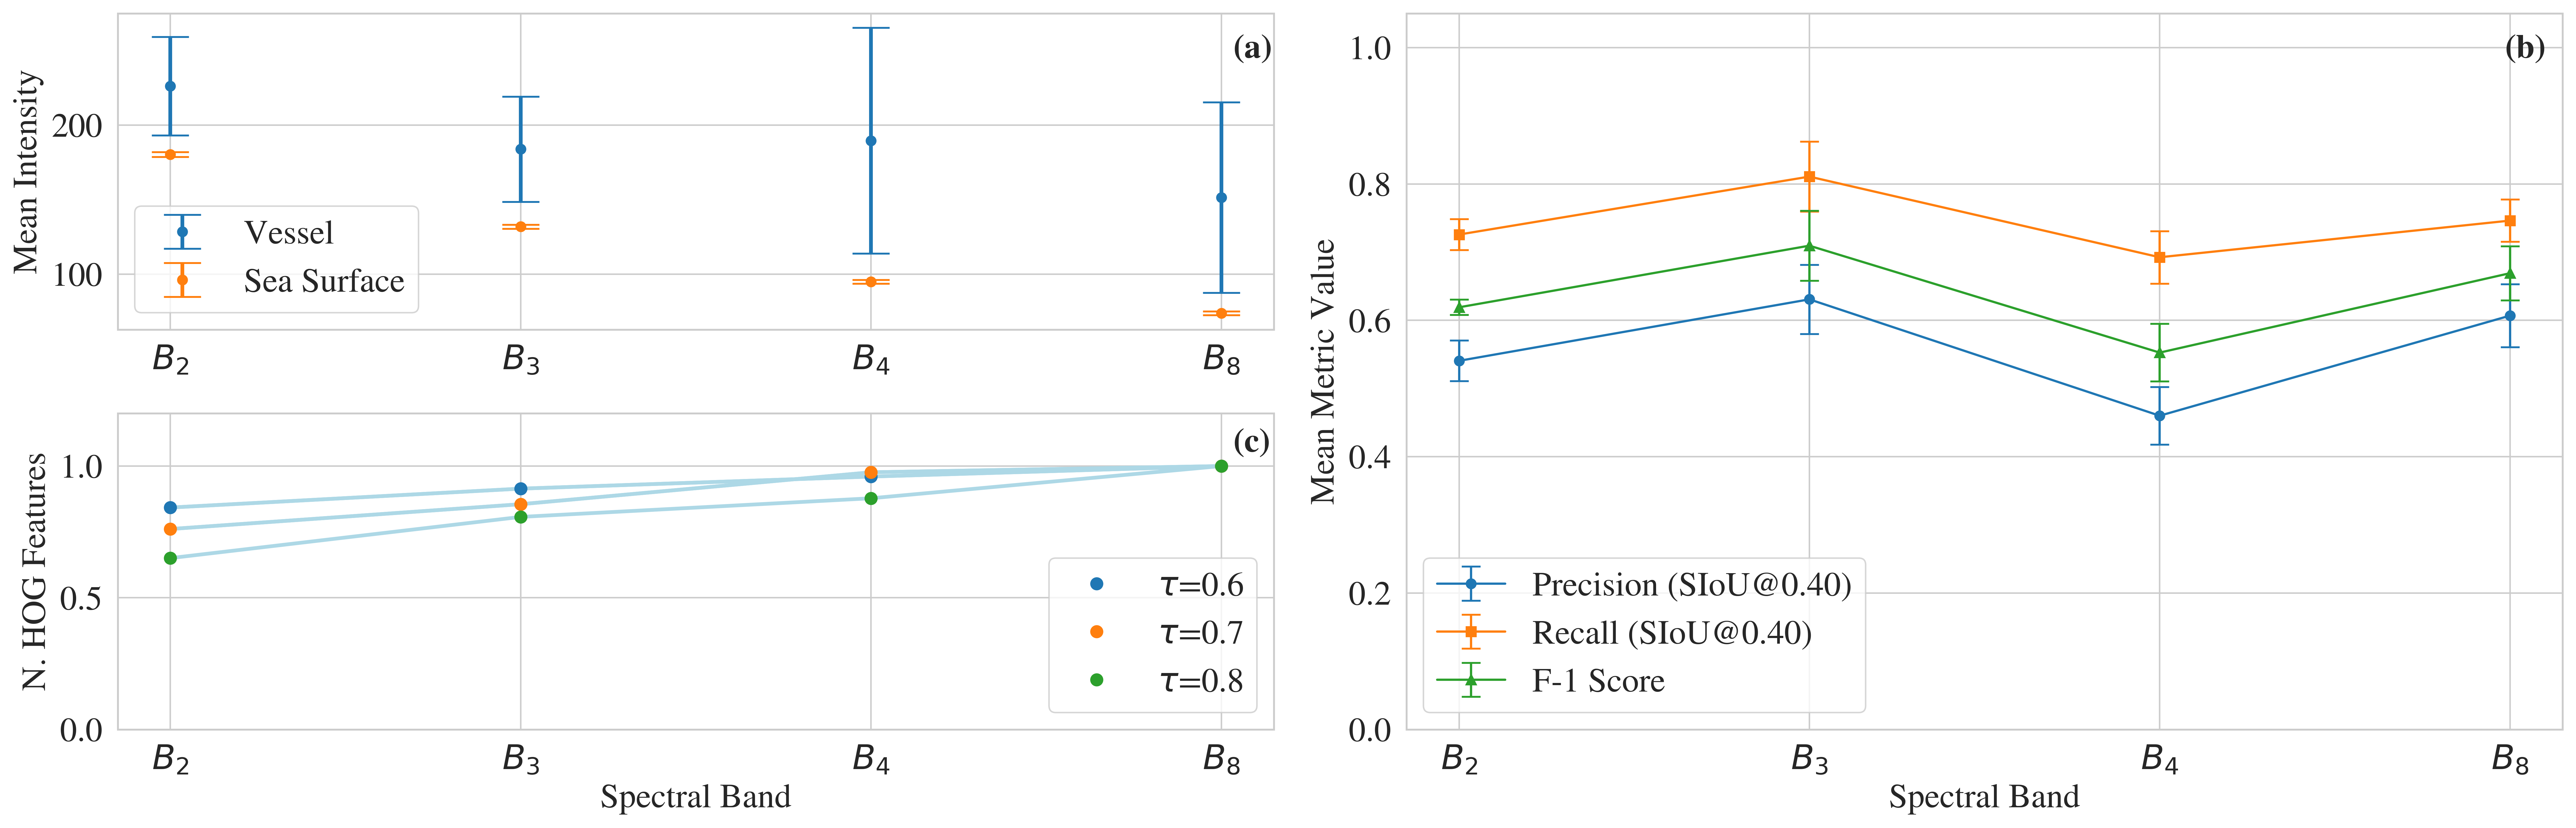

In [60]:
import matplotlib.pyplot as plt
from style import set_style
import numpy as np
import pandas as pd

set_style(scale_factor=1.3, fontsize=14)
threshold_value = 0.7

plt.subplot(2, 2, 1)
Band = 4
# Plot inside mean value with larger caps and lines
x = range(1, int(Band)+1)
xticks = [f'$B_{{{i}}}$' for i in [2,3,4,8]]
y = [insideResults[x][0]['mean'] for x in range(1, int(Band)+1)]
yerr = [insideResults[x][0]['std'] for x in range(1, int(Band)+1)]
plt.errorbar(x, y, yerr=yerr, fmt='o', label='Vessel', capsize=10, elinewidth=2)

# Plot outside mean value with larger caps and lines
y = [outsideResults[x][0]['mean'] for x in range(1, int(Band)+1)]
yerr = [outsideResults[x][0]['std'] for x in range(1, int(Band)+1)]
plt.errorbar(x, y, yerr=yerr, fmt='o', label='Sea Surface', capsize=10, elinewidth=2)

plt.ylabel('Mean Intensity')
plt.xticks(x, xticks)
plt.legend()

# Calculate the ratio of inside and outside mean values

# plt.subplot(2, 2, 2)
# Plot the ratio of mean values with larger caps and lines


# New Subplot: HOGS
plt.subplot(2, 2, 3)

def get_means_hog(band_num_hog):
    hog_features_by_band = [band_num_hog[band] for band in range(1, 5)]
    all_hog_features = np.concatenate(hog_features_by_band)
    min_val = np.min(all_hog_features)
    max_val = np.max(all_hog_features)
    normalized_all_hog_features = (all_hog_features - min_val) / (max_val - min_val)
    split_indices = np.cumsum([len(band) for band in hog_features_by_band[:-1]])
    normalized_hog_features_by_band = np.split(normalized_all_hog_features, split_indices)
    means = [np.mean(band) for band in normalized_hog_features_by_band]
    means = [i/np.max(means) for i in means]
    return means


threshold_value = 0.6
band_num_hog = pd.read_pickle(f'sen_hog_results/band_num_hog_{threshold_value}.pkl')
means = get_means_hog(band_num_hog)
plt.plot(range(0, len(means)), means, linestyle='-', color='lightblue', linewidth=2)
plt.plot(range(0, 4), means, linestyle='-', color='lightblue', linewidth=2) 
plt.errorbar(range(0, 4), means, yerr=None, fmt='o', capsize=10, elinewidth=2, capthick=1, markersize=6, label=f'$ \\tau $={threshold_value}')


threshold_value = 0.7
band_num_hog = pd.read_pickle(f'sen_hog_results/band_num_hog_{threshold_value}.pkl')
means = get_means_hog(band_num_hog)
plt.plot(range(0, len(means)), means, linestyle='-', color='lightblue', linewidth=2)
plt.plot(range(0, 4), means, linestyle='-', color='lightblue', linewidth=2) 
plt.errorbar(range(0, 4), means, yerr=None, fmt='o', capsize=10, elinewidth=2, capthick=1, markersize=6, label=f'$ \\tau $={threshold_value}')

threshold_value = 0.8
band_num_hog = pd.read_pickle(f'sen_hog_results/band_num_hog_{threshold_value}.pkl')
means = get_means_hog(band_num_hog)
plt.plot(range(0, 4), means, linestyle='-', color='lightblue', linewidth=2) 
plt.errorbar(range(0, 4), means, yerr=None, fmt='o', capsize=10, elinewidth=2, capthick=1, markersize=6, label=f'$ \\tau $={threshold_value}')



# Customizing the plot
# plt.title('Distribution of HOG Features by Band')
plt.xlabel('Spectral Band')
plt.ylabel('N. HOG Features')
plt.legend()
plt.xticks(range(0, 4, 1), [f'$B_{{{i}}}$' for i in [2,3,4,8]])
plt.ylim([0.,1.2])




# New Subplot: Plot the ratio of inside to outside standard deviations
plt.subplot(1, 2, 2)



B2 = {'mean_precision': 0.5406296002300695, 'std_precision': 0.029740179828519522, 'mean_recall': 0.7258064516129032, 'std_recall': 0.022809896167307966, 'mean_f1_score': 0.6191134813656188, 'std_f1_score': 0.011226138600412756}
B3 = {'mean_precision': 0.6307613444218968, 'std_precision': 0.05055622488956747, 'mean_recall': 0.810752688172043, 'std_recall': 0.05134338230672397, 'mean_f1_score': 0.7094604650659293, 'std_f1_score': 0.051468796697921336}
B4 = {'mean_precision': 0.4601009314939457, 'std_precision': 0.04224113732748294, 'mean_recall': 0.6924731182795699, 'std_recall': 0.038469986709673824, 'mean_f1_score': 0.5526458100799945, 'std_f1_score': 0.04226235035901068}
B8 = {'mean_precision': 0.6068594094341739, 'std_precision': 0.04620931077619021, 'mean_recall': 0.746236559139785, 'std_recall': 0.030978194173952516, 'mean_f1_score': 0.6691179517984136, 'std_f1_score': 0.039588212989288635}

data = {
    'Band': ['B2', 'B3', 'B4', 'B8'],
    'mean_P': [B2['mean_precision'], B3['mean_precision'], B4['mean_precision'], B8['mean_precision']],
    'std_P': [B2['std_precision'], B3['std_precision'], B4['std_precision'], B8['std_precision']],
    'mean_R': [B2['mean_recall'], B3['mean_recall'], B4['mean_recall'], B8['mean_recall']],
    'std_R': [B2['std_recall'], B3['std_recall'], B4['std_recall'], B8['std_recall']],
    'mean_F1': [B2['mean_f1_score'], B3['mean_f1_score'], B4['mean_f1_score'], B8['mean_f1_score']],
    'std_F1': [B2['std_f1_score'], B3['std_f1_score'], B4['std_f1_score'], B8['std_f1_score']]
}

grouped = pd.DataFrame(data)

# Plotting the error bars for each metric
plt.errorbar(grouped['Band'], grouped['mean_P'], yerr=grouped['std_P'], 
                label='Precision (SIoU@0.40)', fmt='-o', capsize=5)

plt.errorbar(grouped['Band'], grouped['mean_R'], yerr=grouped['std_R'], 
                label='Recall (SIoU@0.40)', fmt='-s', capsize=5)

plt.errorbar(grouped['Band'], grouped['mean_F1'], yerr=grouped['std_F1'], 
                label='F-1 Score', fmt='-^', capsize=5)



plt.ylim([0.,1.05])
plt.ylabel('Mean Metric Value')
plt.xlabel('Spectral Band')
plt.xticks(range(0, 4, 1), [f'$B_{{{i}}}$' for i in [2,3,4,8]])
plt.legend(loc='lower left')
plt.tight_layout()

# add text (a), (b), (c)
plt.text(-0.15, .97, '(a)', transform=plt.gca().transAxes, fontsize=18, fontweight='bold', va='top')
plt.text(.95, .97, '(b)', transform=plt.gca().transAxes, fontsize=18, fontweight='bold', va='top')
plt.text(-0.15, .42, '(c)', transform=plt.gca().transAxes, fontsize=18, fontweight='bold', va='top')
plt.savefig('/Data_large/marine/PythonProjects/MMDET/results/Fig9.png')
plt.show()